# 03 PyQSAR3 Modeling

## Step 3.1: Native PyQSAR3 Pre-Filtering

This notebook restarts Phase 3 from the raw Mordred descriptor outputs and performs only pre-filtering. Native PyQSAR3 filtering tools are used for non-numeric, missing, infinite, and zero-variance descriptor cleanup. A train-set-only Pearson correlation pass is then applied because the installed PyQSAR3 package does not expose a dedicated high-correlation pre-filter function.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from pyqsar import data_tools as dt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAIN_IN = PROJECT_ROOT / "data" / "features" / "mordred_train.csv"
TEST_IN = PROJECT_ROOT / "data" / "features" / "mordred_test.csv"
TRAIN_OUT = PROJECT_ROOT / "data" / "features" / "filtered_train_pyqsar3.csv"
TEST_OUT = PROJECT_ROOT / "data" / "features" / "filtered_test_pyqsar3.csv"

ID_COLUMNS = ["SMILES", "logKoc"]
CORRELATION_THRESHOLD = 0.90

assert TRAIN_IN.exists(), f"Missing input file: {TRAIN_IN}"
assert TEST_IN.exists(), f"Missing input file: {TEST_IN}"


## Load Raw Mordred Descriptor Tables

The Phase 2 outputs are loaded as fixed inputs. `SMILES` and `logKoc` are preserved while descriptor columns are filtered strictly from Training-set decisions.

In [2]:
train_raw = pd.read_csv(TRAIN_IN)
test_raw = pd.read_csv(TEST_IN)

assert train_raw.shape == (514, 1615), f"Unexpected train shape: {train_raw.shape}"
assert test_raw.shape == (128, 1615), f"Unexpected test shape: {test_raw.shape}"
assert list(train_raw.columns) == list(test_raw.columns), "Train/Test raw schemas differ"
assert train_raw.columns[:2].tolist() == ID_COLUMNS, "Expected SMILES/logKoc as the first columns"

train_meta = train_raw[ID_COLUMNS].copy()
test_meta = test_raw[ID_COLUMNS].copy()
X_train_raw = train_raw.drop(columns=ID_COLUMNS).copy()
X_test_raw = test_raw.drop(columns=ID_COLUMNS).copy()

print(f"Raw Train shape: {train_raw.shape}")
print(f"Raw Test shape: {test_raw.shape}")
print(f"Raw descriptor count: {X_train_raw.shape[1]}")


Raw Train shape: (514, 1615)
Raw Test shape: (128, 1615)
Raw descriptor count: 1613


## Native PyQSAR3 Filtering Helpers

PyQSAR3's `FilteringTools` expects the first three columns to be `ID`, endpoint, and SMILES, with descriptors starting at column index 3. The helper below adapts the existing `SMILES`/`logKoc` tables to that native layout, calls the native methods, and returns the selected descriptor columns for application to both Train and Test sets.

In [3]:
def to_pyqsar_format(meta: pd.DataFrame, X: pd.DataFrame) -> pd.DataFrame:
    return pd.concat(
        [
            pd.Series(np.arange(1, len(meta) + 1), name="ID"),
            meta["logKoc"].rename("EP").reset_index(drop=True),
            meta["SMILES"].rename("SMI").reset_index(drop=True),
            X.reset_index(drop=True),
        ],
        axis=1,
    )


def make_filtering_tool(pyqsar_df: pd.DataFrame):
    tool = dt.FilteringTools.__new__(dt.FilteringTools)
    tool.X_data = pyqsar_df.copy()
    tool.X_data_ = pyqsar_df.copy()
    tool.nan_list = []
    tool.novar_list = []
    tool.inf_list = []
    tool.etc_list = []
    tool.etc_val_list = []
    return tool


def selected_descriptors_from_pyqsar_frame(pyqsar_df: pd.DataFrame) -> list[str]:
    return pyqsar_df.columns[3:].tolist()


## Native PyQSAR3 Non-Numeric, Missing, Infinite, and Zero-Variance Filters

The library-native `dt.NonNumricFilter` mirrors the project example and removes non-numeric/all-zero descriptors. `FilteringTools.rm_nan`, `rm_inf`, and `rm_novar` are then fitted on the Training set only. The resulting Training descriptor list is applied to the Test set unchanged.

In [4]:
# Native pyqsar3 example filter: numeric and non-all-zero descriptors.
X_train_numeric, numeric_descriptors = dt.NonNumricFilter(X_train_raw)
X_test_numeric = X_test_raw[numeric_descriptors].copy()

pyqsar_train_numeric = to_pyqsar_format(train_meta, X_train_numeric)
filter_tool = make_filtering_tool(pyqsar_train_numeric)

after_nan = filter_tool.rm_nan()
after_inf = filter_tool.rm_inf()
after_novar = filter_tool.rm_novar()

native_filtered_descriptors = selected_descriptors_from_pyqsar_frame(after_novar)
X_train_native = X_train_raw[native_filtered_descriptors].copy()
X_test_native = X_test_raw[native_filtered_descriptors].copy()

native_removed = X_train_raw.shape[1] - len(native_filtered_descriptors)

print(f"Descriptors after native PyQSAR3 filters: {len(native_filtered_descriptors)}")
print(f"Descriptors removed by native PyQSAR3 filters: {native_removed}")
print(f"Train native-filtered descriptor shape: {X_train_native.shape}")
print(f"Test native-filtered descriptor shape: {X_test_native.shape}")

assert X_train_native.shape[1] == X_test_native.shape[1], "Train/Test native-filtered feature counts differ"
assert list(X_train_native.columns) == list(X_test_native.columns), "Train/Test native-filtered schemas differ"
assert not X_train_native.isna().any().any(), "Training NaNs remain after native rm_nan"
assert np.isfinite(X_train_native.to_numpy(dtype=float)).all(), "Training Inf values remain after native rm_inf"


Start :  (514, 1613)
Filterd : (514, 1446)
NaN       : 491
Inf       : 0


No Var    : 0
Descriptors after native PyQSAR3 filters: 955
Descriptors removed by native PyQSAR3 filters: 658
Train native-filtered descriptor shape: (514, 955)
Test native-filtered descriptor shape: (128, 955)


## Train-Set Pearson High-Correlation Filter

The installed PyQSAR3 package provides correlation visualization utilities but no dedicated high-correlation pre-filter method. To complete the required pre-filtering while preserving the no-leakage rule, Pearson correlations are computed strictly on the Training descriptors that survived native PyQSAR3 filtering. The same dropped columns are then removed from the Test set.

In [5]:
corr_matrix = X_train_native.corr(method="pearson").abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
correlation_drop_columns = [
    column for column in upper_triangle.columns
    if (upper_triangle[column] > CORRELATION_THRESHOLD).any()
]

X_train_filtered = X_train_native.drop(columns=correlation_drop_columns)
X_test_filtered = X_test_native.drop(columns=correlation_drop_columns)

print(f"Correlation threshold: abs(r) > {CORRELATION_THRESHOLD}")
print(f"Highly correlated descriptors removed: {len(correlation_drop_columns)}")
print(f"Final descriptor count: {X_train_filtered.shape[1]}")

assert X_train_filtered.shape[1] == X_test_filtered.shape[1], "Train/Test final feature counts differ"
assert list(X_train_filtered.columns) == list(X_test_filtered.columns), "Train/Test final schemas differ"


Correlation threshold: abs(r) > 0.9
Highly correlated descriptors removed: 578
Final descriptor count: 377


## Save PyQSAR3-Filtered Outputs

The final outputs retain `SMILES`, `logKoc`, and the surviving descriptors. No Test-set statistics are used to fit any filter.

In [6]:
filtered_train = pd.concat(
    [train_meta.reset_index(drop=True), X_train_filtered.reset_index(drop=True)],
    axis=1,
)
filtered_test = pd.concat(
    [test_meta.reset_index(drop=True), X_test_filtered.reset_index(drop=True)],
    axis=1,
)

assert filtered_train.shape[0] == train_raw.shape[0], "Train row count changed"
assert filtered_test.shape[0] == test_raw.shape[0], "Test row count changed"
assert list(filtered_train.columns) == list(filtered_test.columns), "Filtered Train/Test schemas differ"

TRAIN_OUT.parent.mkdir(parents=True, exist_ok=True)
filtered_train.to_csv(TRAIN_OUT, index=False)
filtered_test.to_csv(TEST_OUT, index=False)

print(f"Saved Train output: {TRAIN_OUT}")
print(f"Saved Test output: {TEST_OUT}")
print(f"Final Train shape: {filtered_train.shape}")
print(f"Final Test shape: {filtered_test.shape}")


Saved Train output: /home/jun/Documents/qsar_modeling/data/features/filtered_train_pyqsar3.csv
Saved Test output: /home/jun/Documents/qsar_modeling/data/features/filtered_test_pyqsar3.csv
Final Train shape: (514, 379)
Final Test shape: (128, 379)


## Step 3.2: Native PyQSAR3 Feature Clustering

This corrected section performs native PyQSAR3 descriptor clustering for downstream GA/MC feature-selection engines. PyQSAR3 clusters descriptor columns, not compound rows, so the previous row-wise partition files are removed and the filtered training descriptor matrix remains the single source of truth.

In [7]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

from pyqsar import model_tools as mt

STEP32_ROOT = PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()
if STEP32_ROOT.name == "notebooks":
    STEP32_ROOT = STEP32_ROOT.parent

FEATURE_DIR = STEP32_ROOT / "data" / "features"
FILTERED_TRAIN_PATH = FEATURE_DIR / "filtered_train_pyqsar3.csv"
FEATURE_CLUSTER_JSON = FEATURE_DIR / "feature_clusters_pyqsar3.json"
FEATURE_CLUSTER_STEM = FEATURE_DIR / "feature_clusters_pyqsar3"

ROW_WISE_TRACK_FILES = [
    FEATURE_DIR / "train_track_hierarchical_pyqsar3.csv",
    FEATURE_DIR / "train_track_kmeans_pyqsar3.csv",
    FEATURE_DIR / "train_track_som_pyqsar3.csv",
]

TARGET_FEATURE_CLUSTERS = 20
KMEANS_FEATURE_CLUSTERS = 20
SOM_MAP_SIZE = 5
SOM_RANDOM_SEED = 42

print(f"Feature directory: {FEATURE_DIR}")

Feature directory: /home/jun/Documents/qsar_modeling/data/features


### Roll Back Incorrect Row-Wise Track Outputs

The three row-partitioned training tables are not compatible with PyQSAR3 GA/MC selection, which expects feature-cluster assignments. This cell removes those obsolete artifacts if they exist.

In [8]:
deleted_row_track_files = []
for path in ROW_WISE_TRACK_FILES:
    if path.exists():
        path.unlink()
        deleted_row_track_files.append(str(path))

if deleted_row_track_files:
    print("Deleted obsolete row-wise track files:")
    for path in deleted_row_track_files:
        print(f"- {path}")
else:
    print("No obsolete row-wise track files were present.")

No obsolete row-wise track files were present.


### Load PyQSAR3-Filtered Descriptors

The filtered training table contains `SMILES`, `logKoc`, and 377 retained descriptors. The native K-Means and SOM feature cluster classes expect a PyQSAR-style table whose first three columns are metadata, so a compatibility table is created while preserving all descriptor columns for clustering.

In [9]:
train_filtered = pd.read_csv(FILTERED_TRAIN_PATH)
assert train_filtered.shape == (514, 379), f"Unexpected filtered train shape: {train_filtered.shape}"
assert {"SMILES", "logKoc"}.issubset(train_filtered.columns), "Required SMILES/logKoc columns missing."

ID_COLUMNS = ["SMILES", "logKoc"]
X_train = train_filtered.drop(columns=ID_COLUMNS).copy()
assert X_train.shape == (514, 377), f"Unexpected descriptor matrix shape: {X_train.shape}"
assert X_train.columns.is_unique, "Descriptor names must be unique before feature clustering."

pyqsar_metadata = pd.DataFrame({
    "Name": [f"train_{idx:04d}" for idx in range(len(train_filtered))],
    "Cid": np.arange(len(train_filtered)),
    "Smiles": train_filtered["SMILES"].astype(str),
})
pyqsar_feature_input = pd.concat(
    [pyqsar_metadata.reset_index(drop=True), X_train.reset_index(drop=True)],
    axis=1,
)

assert pyqsar_feature_input.shape == (514, 380), f"Unexpected PyQSAR-compatible shape: {pyqsar_feature_input.shape}"
print(f"Filtered train table: {train_filtered.shape}")
print(f"Descriptor matrix for feature clustering: {X_train.shape}")
print(f"PyQSAR-compatible feature table: {pyqsar_feature_input.shape}")

Filtered train table: (514, 379)
Descriptor matrix for feature clustering: (514, 377)
PyQSAR-compatible feature table: (514, 380)


### Helper Functions for Cluster Mapping

The JSON output stores a descriptor-to-cluster mapping for each native method, plus cluster counts for quick verification. The mapping is intentionally based only on the 377 descriptor columns.

In [10]:
def feature_assignment_mapping(feature_names, assignments):
    if len(feature_names) != len(assignments):
        raise ValueError(f"Feature/assignment length mismatch: {len(feature_names)} vs {len(assignments)}")
    return {feature: int(cluster) for feature, cluster in zip(feature_names, assignments)}


def cluster_count(mapping):
    return len(set(mapping.values()))


def cluster_size_summary(mapping):
    counts = {}
    for cluster in mapping.values():
        counts[str(cluster)] = counts.get(str(cluster), 0) + 1
    return dict(sorted(counts.items(), key=lambda item: int(item[0])))


def choose_hierarchical_cut(abs_corr, target_clusters=20, linkage_method="average"):
    linkage_matrix = mt.linkage(abs_corr, method=linkage_method)
    max_distance = float(linkage_matrix[:, 2].max())
    candidate_cuts = np.linspace(0.01, max_distance, 1000)
    best_cut = None
    best_count = None
    best_delta = None
    for cut in candidate_cuts:
        labels = mt.fcluster(linkage_matrix, cut, "distance") - 1
        count = len(np.unique(labels))
        delta = abs(count - target_clusters)
        if best_delta is None or delta < best_delta or (delta == best_delta and cut < best_cut):
            best_cut = float(cut)
            best_count = int(count)
            best_delta = int(delta)
    return best_cut, best_count

### Native PyQSAR3 Feature Clustering

Three native PyQSAR3 feature-clustering methods are applied: hierarchical clustering (`FeatureCluster`), K-Means (`FeatureCluster_KMeans`), and SOM (`FeatureCluster_Minisom`). The PyQSAR3 `data_name` stem is pointed into `data/features` so the native `.cluster` sidecar files are written with the rest of the feature artifacts.


 Cluster 0 ['ATS0Z', 'ATS2Z', 'ATS3Z', 'BCUTd-1h', 'SM1_DzZ', 'Xc-3d', 'Xc-4d', 'Xc-3dv', 'Xpc-4d', 'Xpc-4dv', 'ETA_shape_x', 'AETA_eta'] 
 Cluster 1 ['nBridgehead', 'ATSC3d', 'C3SP3', 'Xch-6d', 'Xc-5d', 'Xc-6d', 'Xc-5dv', 'NssssC', 'SssssC', 'PEOE_VSA5', 'n4Ring', 'n5Ring', 'nARing', 'n5ARing', 'nFARing', 'n10FARing', 'SRW05'] 
 Cluster 2 ['nN', 'ATSC2c', 'ATSC3c', 'ATSC4c', 'ATSC5dv', 'ATSC5se', 'AATSC2c', 'MATS1c', 'MATS2c', 'NssNH', 'NaaN', 'PEOE_VSA12', 'SMR_VSA3', 'SlogP_VSA1', 'nHRing', 'n6HRing', 'naHRing'] 
 Cluster 3 ['nAcid', 'nBase', 'VR1_A', 'nBr', 'ATSC7c', 'ATSC8c', 'ATSC4dv', 'ATSC6dv', 'ATSC4d', 'ATSC6d', 'ATSC7d', 'ATSC8d', 'ATSC3s', 'ATSC3Z', 'ATSC4Z', 'ATSC5Z', 'ATSC6Z', 'ATSC7Z', 'ATSC8Z', 'ATSC3v', 'ATSC4v', 'ATSC5v', 'ATSC6v', 'ATSC7v', 'ATSC8v', 'ATSC1se', 'ATSC3se', 'ATSC3p', 'ATSC4p', 'ATSC5p', 'ATSC6p', 'ATSC7p', 'ATSC8p', 'ATSC4i', 'ATSC5i', 'ATSC6i', 'ATSC7i', 'ATSC8i', 'AATSC1se', 'MATS1s', 'GATS2c', 'GATS1se', 'GATS2i', 'nBondsT', 'C2SP1', 'C1SP2', 'C4SP


 Cluster 0 ['ABC', 'nAcid', 'nBase', 'SpMax_A', 'SpMAD_A', 'nAromAtom', 'nAtom', 'nBridgehead', 'nHetero', 'nN', 'nO', 'nS', 'nP', 'nF', 'nCl', 'nBr', 'ATS7dv', 'AATS0dv', 'AATS0d', 'AATS0s', 'AATS1s', 'AATS0Z', 'AATS2Z', 'AATS0se', 'ATSC0c', 'ATSC1c', 'ATSC2c', 'ATSC3c', 'ATSC4c', 'ATSC5c', 'ATSC6c', 'ATSC7c', 'ATSC8c', 'ATSC1dv', 'ATSC2dv', 'ATSC3dv', 'ATSC4dv', 'ATSC5dv', 'ATSC6dv', 'ATSC7dv', 'ATSC8dv', 'ATSC1d', 'ATSC2d', 'ATSC3d', 'ATSC4d', 'ATSC5d', 'ATSC6d', 'ATSC7d', 'ATSC8d', 'ATSC1s', 'ATSC2s', 'ATSC3s', 'ATSC4s', 'ATSC5s', 'ATSC6s', 'ATSC7s', 'ATSC8s', 'ATSC1Z', 'ATSC2Z', 'ATSC4Z', 'ATSC7Z', 'ATSC8Z', 'ATSC1v', 'ATSC0se', 'ATSC1se', 'ATSC2se', 'ATSC3se', 'ATSC4se', 'ATSC5se', 'ATSC6se', 'ATSC7se', 'ATSC8se', 'ATSC0p', 'ATSC1p', 'ATSC2p', 'ATSC3p', 'ATSC4p', 'ATSC5p', 'ATSC6p', 'ATSC7p', 'ATSC8p', 'ATSC0i', 'ATSC1i', 'ATSC2i', 'ATSC3i', 'ATSC4i', 'ATSC5i', 'ATSC6i', 'ATSC7i', 'ATSC8i', 'AATSC0c', 'AATSC1c', 'AATSC2c', 'AATSC0dv', 'AATSC1dv', 'AATSC0d', 'AATSC1d', 'AATSC2d',

Quantization Error : 465.3185846965222

 Cluster 0 ['ATSC5dv', 'ATSC5s', 'ATSC5Z'] 
 Cluster 1 ['nAtom', 'ATSC1dv', 'BCUTv-1h', 'PEOE_VSA6', 'PEOE_VSA7'] 
 Cluster 2 ['EState_VSA5', 'EState_VSA8'] 
 Cluster 3 ['ATSC3dv', 'ATSC4dv'] 
 Cluster 4 ['ATSC5v'] 
 Cluster 5 ['ATSC2dv', 'ATSC2s', 'ATSC6s'] 
 Cluster 6 ['AATSC0Z', 'MIC0'] 
 Cluster 7 ['ATSC8dv', 'ATSC8s'] 
 Cluster 8 ['ABC', 'nAromAtom', 'AATS0dv', 'AATS0se', 'ATSC0p', 'BCUTs-1h', 'BCUTZ-1h', 'BCUTv-1l', 'BCUTi-1h', 'BCUTi-1l', 'PEOE_VSA1', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA5', 'SMR_VSA6', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA5', 'EState_VSA1', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA6', 'EState_VSA7', 'VSA_EState1', 'VSA_EState2'] 
 Cluster 9 ['ATSC6Z', 'ATSC6v'] 
 Cluster 10 ['ATSC1Z'] 
 Cluster 11 ['ATSC6dv', 'ATSC7dv', 'ATSC7s'] 
 Cluster 12 ['ATSC4Z', 'ATSC4v'] 
 Cluster 13 ['ATS0dv', 'AATS0v', 'AATS0i', 'AATS1i', 'AATS2i'] 
 Cluster 14 ['ATSC7Z', 'ATSC7v'] 
 Cluster 15 ['nAcid', 'nBase', 'SpMax_A', 'SpMAD_

Native PyQSAR3 feature clustering complete.
Hierarchical distance cut selected: 3.3209 (estimated clusters: 20)
Hierarchical: 20 feature clusters
KMeans: 20 feature clusters
SOM: 25 feature clusters


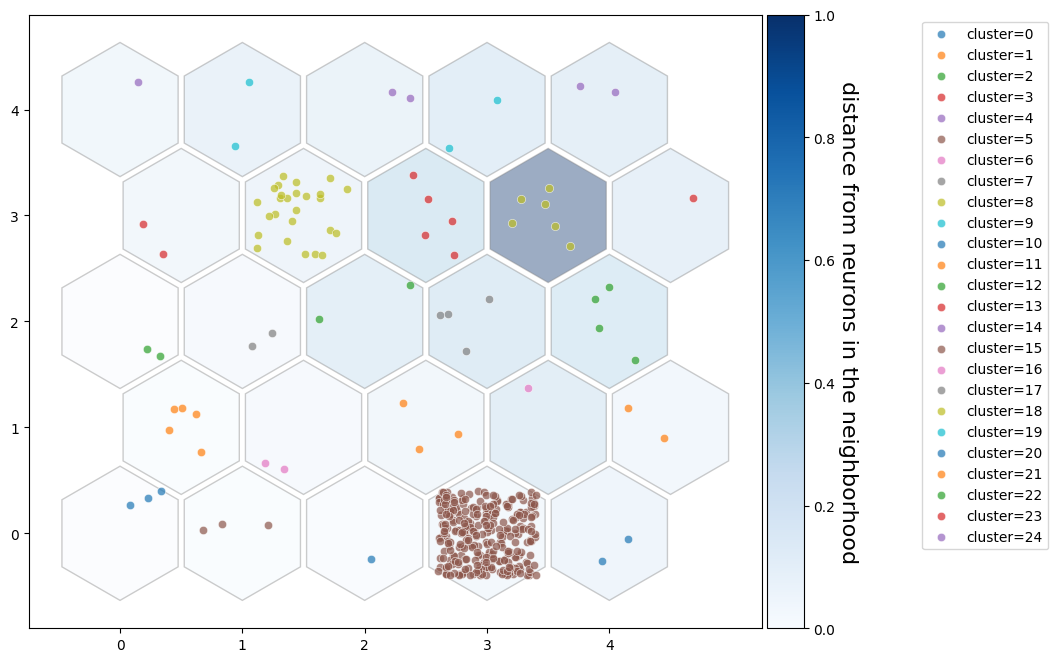

In [11]:
FEATURE_DIR.mkdir(parents=True, exist_ok=True)
mt.ds.data_name = str(FEATURE_CLUSTER_STEM)

# Track 1: Hierarchical descriptor clustering. FeatureCluster uses a distance cut,
# so choose the cut closest to the target cluster count, then call the native method.
hierarchical_cut, estimated_hierarchical_clusters = choose_hierarchical_cut(
    abs(X_train.corr()),
    target_clusters=TARGET_FEATURE_CLUSTERS,
    linkage_method="average",
)
hierarchical_clusterer = mt.FeatureCluster(X_train)
hierarchical_assignments = hierarchical_clusterer.set_cluster("average", hierarchical_cut)
hierarchical_mapping = feature_assignment_mapping(X_train.columns.tolist(), hierarchical_assignments)

# Track 2: Native PyQSAR3 K-Means descriptor clustering.
kmeans_clusterer = mt.FeatureCluster_KMeans(
    pyqsar_feature_input,
    n_cluster=KMEANS_FEATURE_CLUSTERS,
    random_state=42,
    init="k-means++",
    algorithm="auto",
)
kmeans_assignments = kmeans_clusterer.set_cluster()
kmeans_mapping = feature_assignment_mapping(X_train.columns.tolist(), kmeans_assignments)

# Track 3: Native PyQSAR3 SOM descriptor clustering. A 5 x 5 map yields up to 25 bins,
# with empty bins compacted internally by PyQSAR3.
som_clusterer = mt.FeatureCluster_Minisom(
    pyqsar_feature_input,
    error="qe",
    random_seed=SOM_RANDOM_SEED,
    train=1000,
    neighborhood_function="gaussian",
    topology="hexagonal",
)
som_assignments = som_clusterer.set_cluster(
    map_n=SOM_MAP_SIZE,
    sigma=0.5,
    lr=0.5,
    init="random",
)
som_mapping = feature_assignment_mapping(X_train.columns.tolist(), som_assignments)

# PyQSAR3 writes a SOM diagnostic PNG to the execution directory; remove it so this
# step leaves only the requested notebook and feature-clustering artifacts.
for generated_plot in [
    STEP32_ROOT / "som_seed_qe_hexagonal.png",
    STEP32_ROOT / "notebooks" / "som_seed_qe_hexagonal.png",
]:
    if generated_plot.exists():
        generated_plot.unlink()

feature_cluster_mappings = {
    "Hierarchical": hierarchical_mapping,
    "KMeans": kmeans_mapping,
    "SOM": som_mapping,
}

feature_cluster_counts = {
    method: cluster_count(mapping)
    for method, mapping in feature_cluster_mappings.items()
}

print("Native PyQSAR3 feature clustering complete.")
print(f"Hierarchical distance cut selected: {hierarchical_cut:.4f} (estimated clusters: {estimated_hierarchical_clusters})")
for method, count in feature_cluster_counts.items():
    print(f"{method}: {count} feature clusters")

### Save Feature Cluster Mapping

The JSON mapping records each descriptor's assigned feature cluster for the three native PyQSAR3 clustering tracks. This is a records artifact; Step 3.3 can also consume the live `cluster_info` / assignment objects in this notebook.

In [12]:
feature_cluster_payload = {
    "source_file": str(FILTERED_TRAIN_PATH),
    "n_descriptors": int(X_train.shape[1]),
    "parameters": {
        "target_hierarchical_clusters": TARGET_FEATURE_CLUSTERS,
        "hierarchical_linkage": "average",
        "hierarchical_distance_cut": hierarchical_cut,
        "kmeans_n_cluster": KMEANS_FEATURE_CLUSTERS,
        "som_map_size": SOM_MAP_SIZE,
        "som_sigma": 0.5,
        "som_learning_rate": 0.5,
        "som_random_seed": SOM_RANDOM_SEED,
    },
    "cluster_counts": feature_cluster_counts,
    "cluster_sizes": {
        method: cluster_size_summary(mapping)
        for method, mapping in feature_cluster_mappings.items()
    },
    "mappings": feature_cluster_mappings,
}

with FEATURE_CLUSTER_JSON.open("w", encoding="utf-8") as handle:
    json.dump(feature_cluster_payload, handle, indent=2)

assert FEATURE_CLUSTER_JSON.exists(), f"Missing output JSON: {FEATURE_CLUSTER_JSON}"
assert set(feature_cluster_payload["mappings"].keys()) == {"Hierarchical", "KMeans", "SOM"}
for method, mapping in feature_cluster_payload["mappings"].items():
    assert len(mapping) == 377, f"{method} mapping does not cover all descriptors."

print(f"Saved feature cluster mapping: {FEATURE_CLUSTER_JSON}")
for method, sizes in feature_cluster_payload["cluster_sizes"].items():
    print(f"{method} cluster sizes: {sizes}")

Saved feature cluster mapping: /home/jun/Documents/qsar_modeling/data/features/feature_clusters_pyqsar3.json
Hierarchical cluster sizes: {'0': 12, '1': 17, '2': 17, '3': 111, '4': 12, '5': 5, '6': 9, '7': 19, '8': 14, '9': 10, '10': 5, '11': 8, '12': 29, '13': 38, '14': 20, '15': 11, '16': 14, '17': 13, '18': 4, '19': 9}
KMeans cluster sizes: {'0': 352, '1': 1, '2': 1, '3': 1, '4': 1, '5': 1, '6': 1, '7': 1, '8': 1, '9': 1, '10': 1, '11': 7, '12': 1, '13': 1, '14': 1, '15': 1, '16': 1, '17': 1, '18': 1, '19': 1}
SOM cluster sizes: {'0': 3, '1': 5, '2': 2, '3': 2, '4': 1, '5': 3, '6': 2, '7': 2, '8': 26, '9': 2, '10': 1, '11': 3, '12': 2, '13': 5, '14': 2, '15': 292, '16': 1, '17': 4, '18': 6, '19': 2, '20': 2, '21': 2, '22': 4, '23': 1, '24': 2}
